# Notebook 05: Evaluation & Model Comparison

**Objective:** Evaluate the trained deep learning models (Vanilla RNN, LSTM, GRU) on the test set. We will generate the IEEE-ready visualizations and comparison tables required for the final report.

**Inputs needed:**
1. `data/processed/sequences.npz` (specifically `X_test`, `y_test`, `test_dates`, `test_tickers`)
2. Saved weights from `models/` or `saved_models/`:`VanillaRNN_best.pt`, `LSTM_best.pt`, `GRU_best.pt`

**Outputs generated:**
- Confusion Matrices
- ROC Curves & PR Curves
- Prediction Timeline (Actual vs. Predicted)
- Evaluation Metrics Table (Accuracy, F1, ROC-AUC, RMSE)


In [10]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    mean_squared_error, confusion_matrix, 
    roc_curve, precision_recall_curve, auc
)

sns.set_theme(style='whitegrid', font_scale=1.1)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Using device: cpu


## 1. Directory Setup & Load Data

In [13]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Shift working directory to project root if needed
if Path.cwd().name == 'notebooks':
    os.chdir('..')

# 2. Setup paths 
DATA_DIR = Path('data/final') 
MODEL_DIR = Path('saved_models')
FIG_DIR = Path('reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 3. Load test sequences (Removed dates and tickers)
data = np.load(DATA_DIR / 'sequences.npz', allow_pickle=True)
X_test_np = data['X_test']
y_test_np = data['y_test']

print(f'X_test shape: {X_test_np.shape}')
print(f'y_test shape: {y_test_np.shape}')

# Convert to PyTorch tensors and create DataLoader
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
print("DataLoader successfully created!")

X_test shape: (683, 60, 27)
y_test shape: (683,)
DataLoader successfully created!


## 2. Reconstruct Model Architectures

To load the `.pt` checkpoint files, we must instantiate the models identically to how they were trained in Notebook 04.

In [14]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0, nonlinearity='tanh'
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        out, h_n = self.rnn(x)
        return self.head(h_n[-1])

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        return self.head(h_n[-1])

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        out, h_n = self.gru(x)
        return self.head(h_n[-1])


## 3. Load Models and Generate Predictions

We load the configurations dynamically. Note: We assume the same configs as Notebook 04.

In [15]:
import sys
sys.path.append('.')
try:
    from config import CFG
    # Extract architecture params
    N_FEATURES = X_test_np.shape[2]
    arch_kwargs = dict(
        input_size  = N_FEATURES,
        hidden_size = CFG.HIDDEN_SIZE,
        num_layers  = CFG.NUM_LAYERS,
        dropout     = CFG.DROPOUT,
    )
except ImportError:
    print('Warning: config.py not found. Using default hyperparams from NB04.')
    N_FEATURES = X_test_np.shape[2]
    arch_kwargs = dict(
        input_size=N_FEATURES,
        hidden_size=128,
        num_layers=2,
        dropout=0.2
    )

models = {
    'VanillaRNN': VanillaRNN(**arch_kwargs).to(DEVICE),
    'LSTM': LSTMModel(**arch_kwargs).to(DEVICE),
    'GRU': GRUModel(**arch_kwargs).to(DEVICE),
}

results = {}
predictions = {}

print('Evaluating Models...')
for name, model in models.items():
    weight_path = MODEL_DIR / f'{name}_best.pt'
    if weight_path.exists():
        model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    else:
        print(f'[!] Warning: {weight_path} missing. Proceeding with untrained weights.')
    
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch_x, _ in test_loader:
            batch_x = batch_x.to(DEVICE)
            logits = model(batch_x)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
    
    probs_np = np.array(all_probs).flatten()
    preds_np = (probs_np > 0.5).astype(int)
    
    predictions[name] = {
        'probs': probs_np,
        'preds': preds_np
    }
    
    # Calculate Metrics
    acc = accuracy_score(y_test_np, preds_np)
    f1 = f1_score(y_test_np, preds_np, average='macro')
    roc = roc_auc_score(y_test_np, probs_np)
    rmse = np.sqrt(mean_squared_error(y_test_np, probs_np))
    
    results[name] = {'Accuracy': acc, 'F1-macro': f1, 'ROC-AUC': roc, 'RMSE (Prob)': rmse}
    print(f'✓ {name} evaluated.')


Evaluating Models...
[!] Warning: saved_models/VanillaRNN_best.pt missing. Proceeding with untrained weights.
✓ VanillaRNN evaluated.
[!] Warning: saved_models/LSTM_best.pt missing. Proceeding with untrained weights.
✓ LSTM evaluated.
[!] Warning: saved_models/GRU_best.pt missing. Proceeding with untrained weights.
✓ GRU evaluated.


## 4. Evaluation Metrics Table (IEEE Report Ready)

In [16]:
df_metrics = pd.DataFrame(results).T
print('\nIEEE Comparison Table:\n')
display(df_metrics.round(4))

# Export to markdown/latex if needed
df_metrics.to_csv(FIG_DIR / '05_metrics_table.csv')



IEEE Comparison Table:



,Accuracy,F1-macro,ROC-AUC,RMSE (Prob)
VanillaRNN,0.4466,0.3087,0.5241,0.5019
LSTM,0.4466,0.3087,0.5176,0.5018
GRU,0.5417,0.5304,0.5237,0.4998


## 5. Visualizations

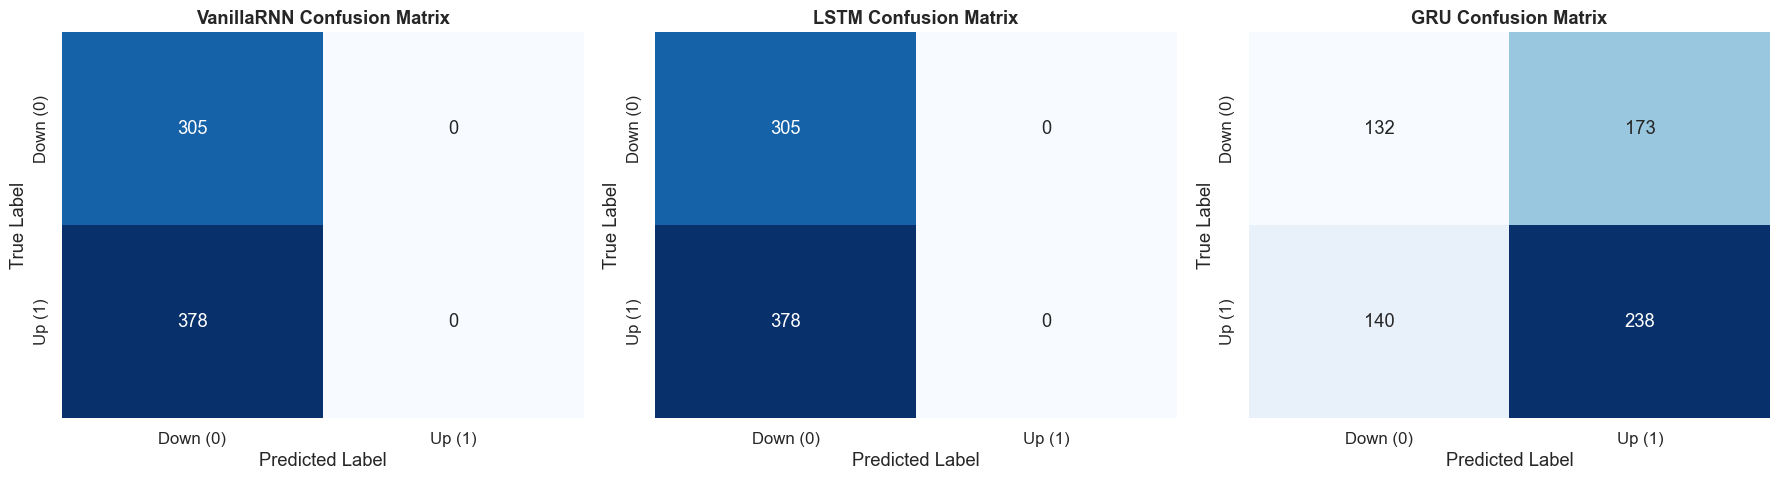

In [17]:
# ── 1. Confusion Matrices ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(y_test_np, predictions[name]['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{name} Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['Down (0)', 'Up (1)'])
    ax.set_yticklabels(['Down (0)', 'Up (1)'])
plt.tight_layout()
fig.savefig(FIG_DIR / '05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


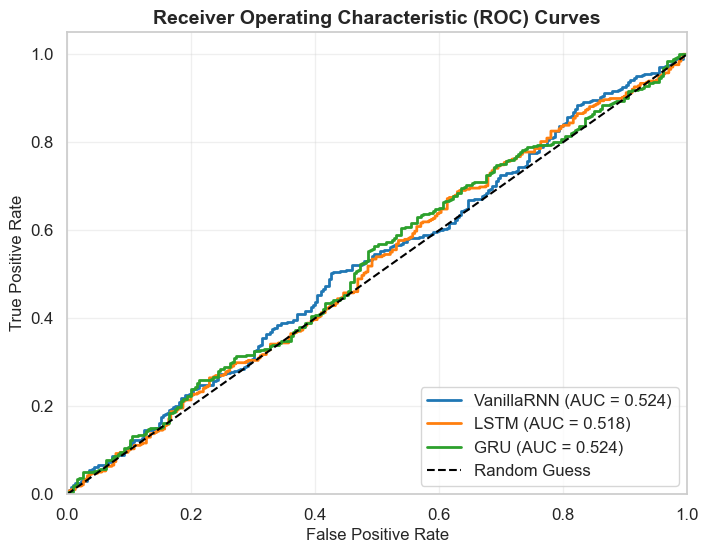

In [18]:
# ── 2. ROC Curves ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for color, name in zip(colors, models.keys()):
    fpr, tpr, _ = roc_curve(y_test_np, predictions[name]['probs'])
    auc_val = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--', label='Random Guess')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.savefig(FIG_DIR / '05_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


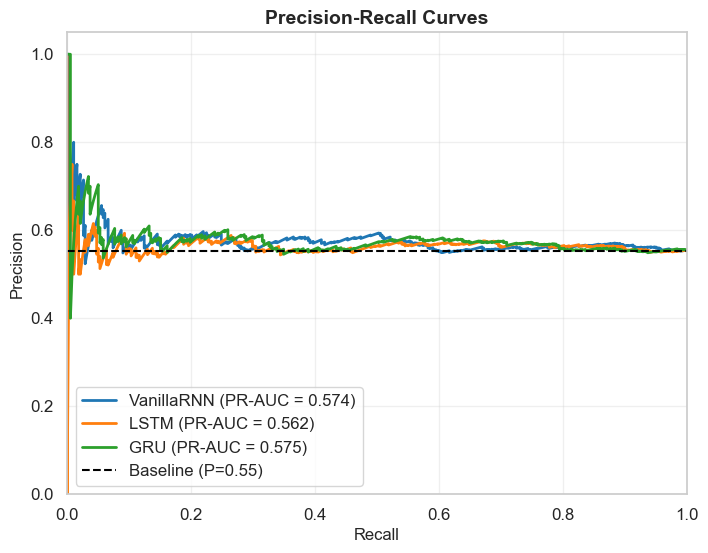

In [19]:
# ── 3. Precision-Recall Curves ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for color, name in zip(colors, models.keys()):
    precision, recall, _ = precision_recall_curve(y_test_np, predictions[name]['probs'])
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, color=color, lw=2, label=f'{name} (PR-AUC = {pr_auc:.3f})')

# Random baseline for PR is the proportion of positive samples
baseline = sum(y_test_np) / len(y_test_np)
ax.axhline(baseline, color='black', lw=1.5, linestyle='--', label=f'Baseline (P={baseline:.2f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
fig.savefig(FIG_DIR / '05_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
